In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#caricamento del dataset di prova
data = load_iris()

In [ ]:
X = data.data  #caratteristiche
y = data.target  #etichette

#divisione dei dati in set di addestramento e di test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

#creazione del modello di classificazione
model = RandomForestClassifier(n_estimators=100, random_state=41)

#addestramento del modello
model.fit(X_train, y_train)

#predizione delle etichette per il set di test
predictions = model.predict(X_test)

#calcolo dell'accuratezza del modello
accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2f}')

Visualizzazione dell'info da cui si nota che non si hanno valori nulli

In [3]:
#analisi dati file iris
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


Con il describe valuto le principali variazioni dei valori 

In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


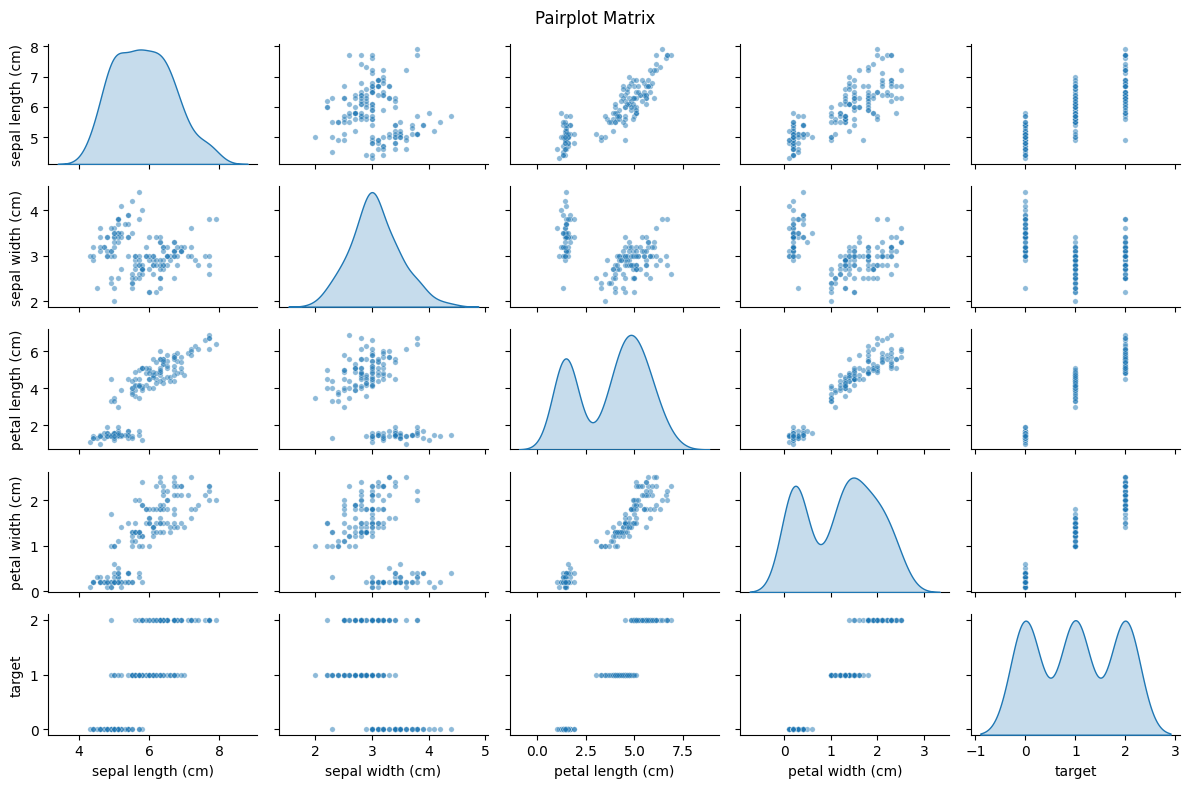

In [4]:
#colonne da mettere come grafico
cols_to_plot = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)", "target"]

#grafico pairplot per visualizzare le caratteristiche generali in realzione tra ogni colonna
g = sns.pairplot(df[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}, diag_kws={'fill': True}, height=2)

g.figure.set_size_inches(12, 8)
g.figure.suptitle('Pairplot Matrix')
plt.tight_layout()
plt.show()

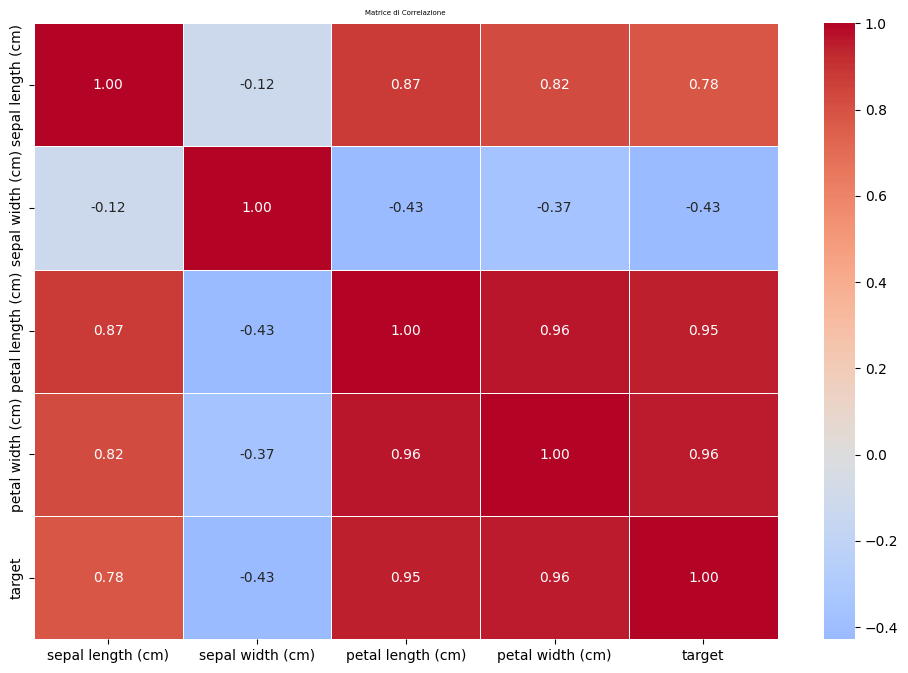

In [9]:
#da regolarne la dimensione
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    fmt=".2f"
)

plt.title('Matrice di Correlazione', fontsize=5)
plt.show()